# Eco-Adaptive Home Storage: Comparative Study

## Multi-Objective Reinforcement Learning for Smart Grid Energy Management

**Authors:** Adam Younsi, Ilyas Madah, Zaid El Kasemy

---

### Objectives
This notebook provides a comprehensive comparative study of different RL agents for home battery management:

1. **Train** a Deep Q-Network (DQN) agent (off-policy, neural network)
2. **Train** a SARSA agent with tile coding (on-policy, linear function approximation)
3. **Compare** with multiple baseline strategies
4. **Evaluate** with statistical rigor (confidence intervals)
5. **Visualize** learning curves, policies, and results

### Environment
- **State Space** $(\mathcal{S} \subset \mathbb{R}^5)$: Hour, SoC, Net Load, Price, Carbon Intensity
- **Action Space** $(\mathcal{A} = \{0, 1, 2\})$: Charge, Discharge, Idle
- **Reward**: $R_t = -(\alpha \cdot \text{Cost}_t + \beta \cdot \text{Emissions}_t + \gamma \cdot |a_t - a_{t-1}|)$

### Agents
| Agent | Type | Description |
|-------|------|-------------|
| **DQN** | Learned (Off-policy) | Deep Q-Network with experience replay and target network |
| **SARSA** | Learned (On-policy) | TD control with tile coding function approximation |
| **Greedy** | Rule-based | Price-based rules (charge when cheap, discharge when expensive) |
| **EcoGreedy** | Rule-based | Carbon-aware rules (prioritize clean grid periods) |
| **Threshold** | Rule-based | Time-based schedule (charge at night, discharge evening) |
| **Random** | Baseline | Uniform random actions (lower bound) |
| **Idle** | Baseline | No storage usage (reference for savings calculation) |

## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Check for PyTorch
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    TORCH_AVAILABLE = True
    print(f'PyTorch available. Device: {DEVICE}')
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = None
    print('PyTorch not available. Will use SARSA agent instead of DQN.')

# Project imports
from rl_glue import RLGlue
from smart_grid_env import SmartGridEnvironment
from sarsa_agent import SarsaAgent, ExpectedSarsaAgent

# Conditional DQN import
if TORCH_AVAILABLE:
    from agents import DQNAgent

from agents import (
    GreedyAgent, EcoGreedyAgent,
    ThresholdAgent, RandomAgent, IdleAgent,
    create_agent, get_agent
)
from experiment import (
    train_agent, evaluate_agent, compare_agents,
    run_policy_episode, compute_statistics,
    plot_training_curves, plot_comparison_bars,
    plot_policy_analysis, plot_action_distribution,
    print_comparison_table, save_results_csv
)

print('All imports successful!')

PyTorch available. Device: cpu
All imports successful!


## 2. Environment Configuration

Define the environment parameters including reward weights.

In [2]:
# Environment parameters
ENV_INFO = {
    # Reward weights (multi-objective)
    'alpha': 1.0,       # Cost weight
    'beta': 0.6,        # Emissions weight  
    'gamma_wear': 0.05, # Action switching penalty
    
    # Battery parameters
    'battery_capacity_kwh': 10.0,
    'max_power_kw': 3.0,
    'eta_charge': 0.95,
    'eta_discharge': 0.95,
    
    # Time parameters
    'steps_per_episode': 48,  # 24h with 30-min steps
    'dt_hours': 0.5,
    
    # Random seed
    'seed': SEED
}

print('Environment Configuration:')
for key, value in ENV_INFO.items():
    print(f'  {key}: {value}')

Environment Configuration:
  alpha: 1.0
  beta: 0.6
  gamma_wear: 0.05
  battery_capacity_kwh: 10.0
  max_power_kw: 3.0
  eta_charge: 0.95
  eta_discharge: 0.95
  steps_per_episode: 48
  dt_hours: 0.5
  seed: 42


## 3. Visualize Environment Dynamics

Let's visualize the synthetic daily profiles generated by the environment.

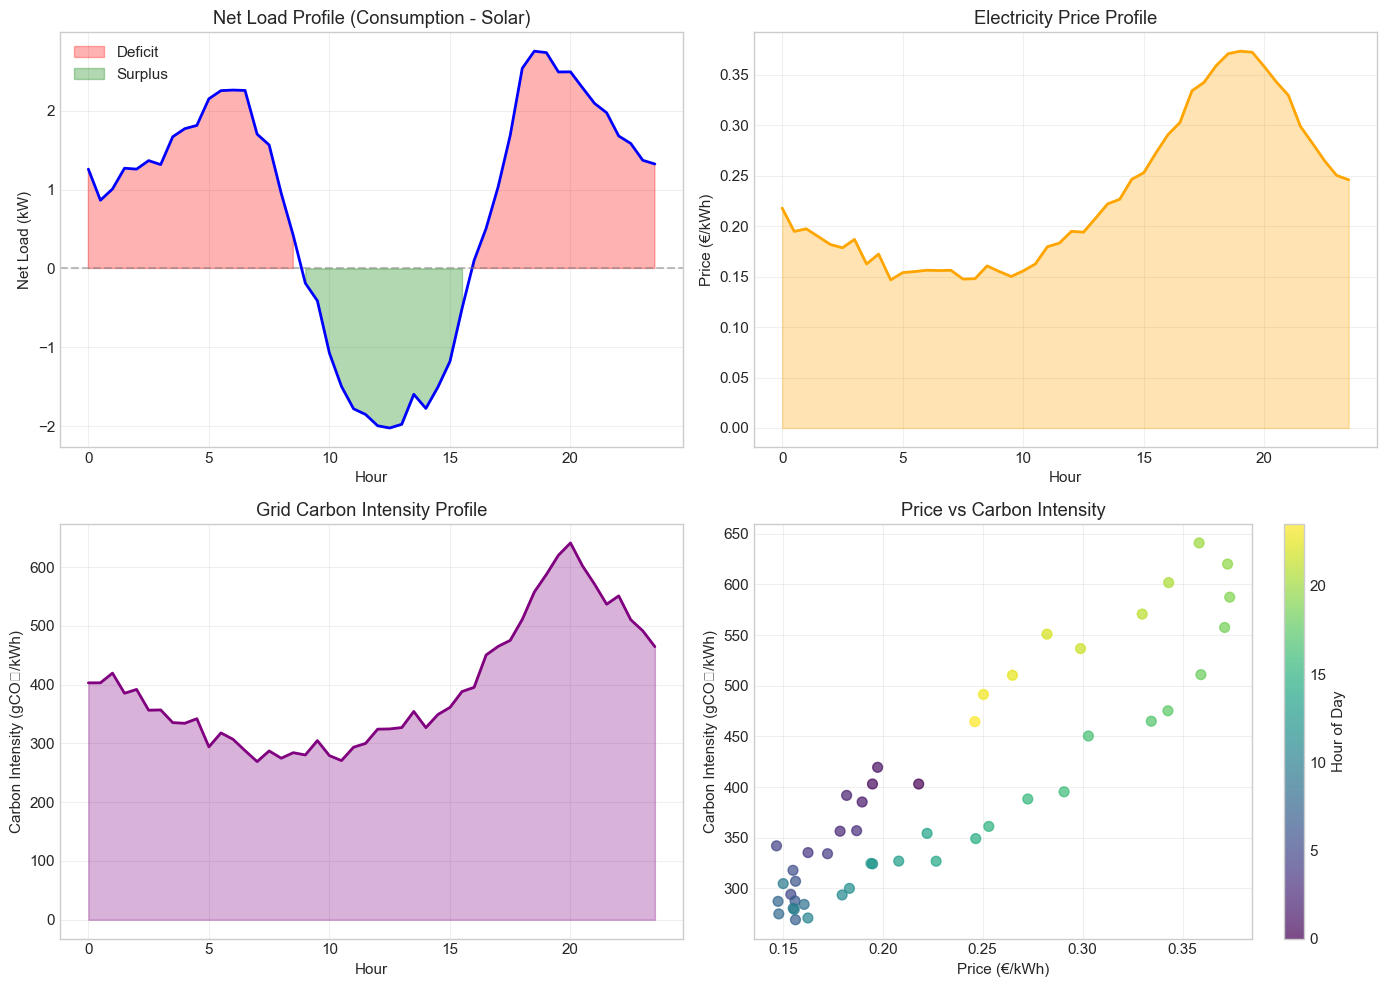

Environment profiles saved to figures/environment_profiles.png


In [3]:
# Create environment and generate profiles
env = SmartGridEnvironment()
env.env_init(ENV_INFO)
env.env_start()

profiles = env.env_message('get_profiles')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hours = profiles['hours']

# Net Load
ax = axes[0, 0]
ax.plot(hours, profiles['p_net'], 'b-', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(hours, 0, profiles['p_net'], 
                where=profiles['p_net'] > 0, alpha=0.3, color='red', label='Deficit')
ax.fill_between(hours, 0, profiles['p_net'], 
                where=profiles['p_net'] < 0, alpha=0.3, color='green', label='Surplus')
ax.set_xlabel('Hour')
ax.set_ylabel('Net Load (kW)')
ax.set_title('Net Load Profile (Consumption - Solar)')
ax.legend()
ax.grid(True, alpha=0.3)

# Price
ax = axes[0, 1]
ax.plot(hours, profiles['prices'], 'orange', linewidth=2)
ax.fill_between(hours, 0, profiles['prices'], alpha=0.3, color='orange')
ax.set_xlabel('Hour')
ax.set_ylabel('Price (€/kWh)')
ax.set_title('Electricity Price Profile')
ax.grid(True, alpha=0.3)

# Carbon
ax = axes[1, 0]
ax.plot(hours, profiles['carbons'], 'purple', linewidth=2)
ax.fill_between(hours, 0, profiles['carbons'], alpha=0.3, color='purple')
ax.set_xlabel('Hour')
ax.set_ylabel('Carbon Intensity (gCO₂/kWh)')
ax.set_title('Grid Carbon Intensity Profile')
ax.grid(True, alpha=0.3)

# Price vs Carbon correlation
ax = axes[1, 1]
scatter = ax.scatter(profiles['prices'], profiles['carbons'], 
                     c=hours, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Hour of Day')
ax.set_xlabel('Price (€/kWh)')
ax.set_ylabel('Carbon Intensity (gCO₂/kWh)')
ax.set_title('Price vs Carbon Intensity')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/environment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Environment profiles saved to figures/environment_profiles.png')

## 4. Train DQN Agent with Hyperparameter Ablation

We train multiple DQN configurations to find the best architecture:
- **Config 1**: Small network [32, 32] - faster, less capacity
- **Config 2**: Medium network [64, 64] - balanced (baseline)
- **Config 3**: Large network [128, 64] - more capacity, slower

This ablation study helps understand the impact of network size on performance.

In [ ]:
# DQN Hyperparameter Configurations for Ablation Study
NUM_EPISODES = 3000  # Training episodes per configuration

# Base configuration (shared parameters)
DQN_BASE = {
    'seed': SEED,
    'device': str(DEVICE),
    'state_dim': 5,
    'action_dim': 3,
    'lr': 5e-4,
    'gamma': 0.99,
    'batch_size': 64,
    'buffer_size': 20000,
    'min_buffer_size': 500,
    'epsilon_start': 1.0,
    'epsilon_end': 0.05,
    'epsilon_decay': 0.995,
    'target_update_freq': 100,
    'training': True
}

# Three DQN configurations with different network architectures
DQN_CONFIGS = {
    'DQN-Small': {'hidden_dims': [32, 32], 'description': 'Small (32x32)'},
    'DQN-Medium': {'hidden_dims': [64, 64], 'description': 'Medium (64x64)'},
    'DQN-Large': {'hidden_dims': [128, 64], 'description': 'Large (128x64)'}
}

print('DQN Ablation Configurations:')
print('='*50)
for name, config in DQN_CONFIGS.items():
    print(f"  {name}: {config['description']}")
print(f'\nEpisodes per config: {NUM_EPISODES}')
print(f'Device: {DEVICE}')

DQN Ablation Configurations:
  DQN-Small: Small (32x32)
  DQN-Medium: Medium (64x64)
  DQN-Large: Large (128x64)

Episodes per config: 3000
Device: cpu


In [ ]:
# Train all DQN configurations
print('\n' + '='*70)
print('DQN HYPERPARAMETER ABLATION STUDY')
print('='*70)

dqn_results = {}
dqn_agents = {}

for name, config in DQN_CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"Training {name} - {config['description']}")
    print('='*50)

    # Create full config
    agent_info = DQN_BASE.copy()
    agent_info['hidden_dims'] = config['hidden_dims']

    # Train
    result = train_agent(
        agent_class=DQNAgent,
        env_class=SmartGridEnvironment,
        agent_info=agent_info,
        env_info=ENV_INFO,
        num_episodes=NUM_EPISODES,
        eval_interval=500,
        verbose=True
    )

    dqn_results[name] = result
    dqn_agents[name] = result.final_agent

    print(f"\n{name} completed in {result.training_time:.1f}s")
    print(f"Final reward (last 100 eps): {np.mean(result.rewards[-100:]):.3f}")

print('\n' + '='*70)
print('DQN ABLATION COMPLETE')
print('='*70)


DQN HYPERPARAMETER ABLATION STUDY

Training DQN-Small - Small (32x32)
Episode 500/3000 | Reward: -20.571 | Cost: €9.119 | ε: 0.606
Episode 1000/3000 | Reward: -17.840 | Cost: €7.988 | ε: 0.368
Episode 1500/3000 | Reward: -16.444 | Cost: €7.480 | ε: 0.223
Episode 2000/3000 | Reward: -15.454 | Cost: €7.143 | ε: 0.135
Episode 2500/3000 | Reward: -14.721 | Cost: €6.887 | ε: 0.082


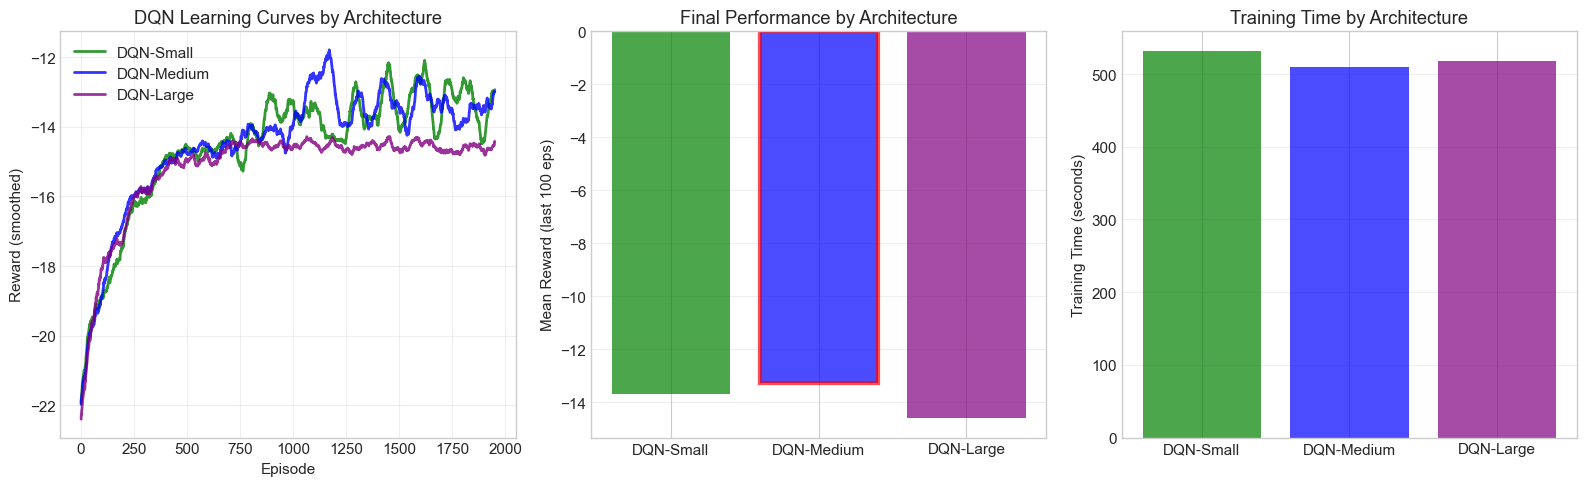


DQN ABLATION SUMMARY
  DQN-Small: Reward=-13.677, Time=532.2s
  DQN-Medium: Reward=-13.260, Time=509.5s <-- BEST
  DQN-Large: Reward=-14.605, Time=518.1s

Selected: DQN-Medium for final comparison


In [ ]:
# Analyze DQN Ablation Results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'DQN-Small': 'green', 'DQN-Medium': 'blue', 'DQN-Large': 'purple'}
window = 50

# 1. Learning curves
ax = axes[0]
for name, result in dqn_results.items():
    smoothed = np.convolve(result.rewards, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, color=colors[name], linewidth=2, label=name, alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('DQN Learning Curves by Architecture')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Final performance comparison
ax = axes[1]
names = list(dqn_results.keys())
final_rewards = [np.mean(dqn_results[n].rewards[-100:]) for n in names]
bars = ax.bar(names, final_rewards, color=[colors[n] for n in names], alpha=0.7)
ax.set_ylabel('Mean Reward (last 100 eps)')
ax.set_title('Final Performance by Architecture')
ax.grid(True, alpha=0.3, axis='y')

# Highlight best
best_idx = np.argmax(final_rewards)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# 3. Training time comparison
ax = axes[2]
train_times = [dqn_results[n].training_time for n in names]
ax.bar(names, train_times, color=[colors[n] for n in names], alpha=0.7)
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time by Architecture')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/dqn_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best DQN
best_dqn_name = names[best_idx]
best_dqn_reward = final_rewards[best_idx]
training_result = dqn_results[best_dqn_name]
dqn_agent = dqn_agents[best_dqn_name]

print('\n' + '='*60)
print('DQN ABLATION SUMMARY')
print('='*60)
for name in names:
    reward = np.mean(dqn_results[name].rewards[-100:])
    time_s = dqn_results[name].training_time
    marker = ' <-- BEST' if name == best_dqn_name else ''
    print(f"  {name}: Reward={reward:.3f}, Time={time_s:.1f}s{marker}")
print('='*60)
print(f"\nSelected: {best_dqn_name} for final comparison")

## 4b. Train SARSA Agent with Tile Coding

SARSA (State-Action-Reward-State-Action) is an **on-policy** TD control algorithm. Unlike DQN which uses a neural network, SARSA here uses **tile coding** for function approximation, similar to the TP05 tutorial.

### Tile Coding Advantages
- **Sparse representation**: Only a few features are active at once
- **Fast updates**: Linear in number of active tiles
- **No neural network required**: Works without PyTorch
- **Interpretable**: Each tiling creates a partition of state space

### Update Rule
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$

In [ ]:
# SARSA Agent configuration with IMPROVED tile coding
# Based on TP05 insights: more tilings with moderate tiles works better

SARSA_INFO = {
    'seed': SEED,

    # IMPROVED Tile coding parameters
    'iht_size': 8192,      # Larger hash table (was 4096)
    'num_tilings': 32,     # More tilings for finer resolution (was 16)
    'num_tiles': 4,        # Coarser tiles per tiling (was 8)

    # Learning parameters
    'alpha': 0.1,          # Step size (will be /num_tilings internally)
    'gamma': 0.99,         # Discount factor

    # Exploration - slower decay for more exploration
    'epsilon_start': 1.0,
    'epsilon_end': 0.02,   # Lower final epsilon (was 0.05)
    'epsilon_decay': 0.998, # Slower decay (was 0.995)

    # Training mode
    'training': True
}

# More training episodes for on-policy learning
SARSA_EPISODES = 3000  # Increased from 2000

print('SARSA Configuration (IMPROVED):')
print('='*50)
print(f"  Tile Coding: {SARSA_INFO['num_tilings']} tilings x {SARSA_INFO['num_tiles']} tiles")
print(f"  IHT Size: {SARSA_INFO['iht_size']}")
print(f"  Episodes: {SARSA_EPISODES}")
print(f"  Epsilon decay: {SARSA_INFO['epsilon_decay']} (slower exploration)")
print('='*50)
print('\nKey improvements:')
print('  - More tilings (32 vs 16) for better resolution')
print('  - Coarser tiles (4 vs 8) to reduce aliasing')
print('  - More episodes (3000 vs 2000) for convergence')
print('  - Slower epsilon decay for more exploration')

SARSA Configuration (IMPROVED):
  Tile Coding: 32 tilings x 4 tiles
  IHT Size: 8192
  Episodes: 3000
  Epsilon decay: 0.998 (slower exploration)

Key improvements:
  - More tilings (32 vs 16) for better resolution
  - Coarser tiles (4 vs 8) to reduce aliasing
  - More episodes (3000 vs 2000) for convergence
  - Slower epsilon decay for more exploration


In [ ]:
# Train both SARSA and Expected SARSA, pick the best
print('\n' + '='*70)
print('SARSA TRAINING (On-Policy TD Control)')
print('='*70)

sarsa_variants = {}

# Train regular SARSA
print('\n--- Training SARSA ---')
sarsa_result_regular = train_agent(
    agent_class=SarsaAgent,
    env_class=SmartGridEnvironment,
    agent_info=SARSA_INFO,
    env_info=ENV_INFO,
    num_episodes=SARSA_EPISODES,
    eval_interval=500,
    verbose=True
)
sarsa_variants['SARSA'] = sarsa_result_regular
print(f"SARSA completed in {sarsa_result_regular.training_time:.1f}s")
print(f"Final reward: {np.mean(sarsa_result_regular.rewards[-100:]):.3f}")

# Train Expected SARSA (lower variance updates)
print('\n--- Training Expected SARSA ---')
exp_sarsa_result = train_agent(
    agent_class=ExpectedSarsaAgent,
    env_class=SmartGridEnvironment,
    agent_info=SARSA_INFO,
    env_info=ENV_INFO,
    num_episodes=SARSA_EPISODES,
    eval_interval=500,
    verbose=True
)
sarsa_variants['ExpSARSA'] = exp_sarsa_result
print(f"Expected SARSA completed in {exp_sarsa_result.training_time:.1f}s")
print(f"Final reward: {np.mean(exp_sarsa_result.rewards[-100:]):.3f}")

# Select best SARSA variant
sarsa_final_rewards = {
    name: np.mean(result.rewards[-100:])
    for name, result in sarsa_variants.items()
}
best_sarsa_name = max(sarsa_final_rewards, key=sarsa_final_rewards.get)
sarsa_result = sarsa_variants[best_sarsa_name]
sarsa_agent = sarsa_result.final_agent

print('\n' + '='*50)
print('SARSA VARIANT COMPARISON')
print('='*50)
for name, reward in sarsa_final_rewards.items():
    marker = ' <-- BEST' if name == best_sarsa_name else ''
    print(f"  {name}: {reward:.3f}{marker}")
print('='*50)
print(f"\nSelected: {best_sarsa_name} for final comparison")


SARSA TRAINING (On-Policy TD Control)

--- Training SARSA ---
Episode 500/3000 | Reward: -19.070 | Cost: €8.416 | ε: 0.368
Episode 1000/3000 | Reward: -15.859 | Cost: €7.022 | ε: 0.135
Episode 1500/3000 | Reward: -13.120 | Cost: €5.921 | ε: 0.050
Episode 2000/3000 | Reward: -11.418 | Cost: €5.245 | ε: 0.020
Episode 2500/3000 | Reward: -11.248 | Cost: €5.175 | ε: 0.020
Episode 3000/3000 | Reward: -11.123 | Cost: €5.129 | ε: 0.020

Training completed in 74.9s
SARSA completed in 74.9s
Final reward: -10.983

--- Training Expected SARSA ---
Episode 500/3000 | Reward: -19.086 | Cost: €8.434 | ε: 0.368
Episode 1000/3000 | Reward: -15.697 | Cost: €6.934 | ε: 0.135
Episode 1500/3000 | Reward: -13.591 | Cost: €6.172 | ε: 0.050
Episode 2000/3000 | Reward: -11.684 | Cost: €5.390 | ε: 0.020
Episode 2500/3000 | Reward: -11.297 | Cost: €5.200 | ε: 0.020
Episode 3000/3000 | Reward: -11.312 | Cost: €5.216 | ε: 0.020

Training completed in 79.2s
Expected SARSA completed in 79.2s
Final reward: -11.243



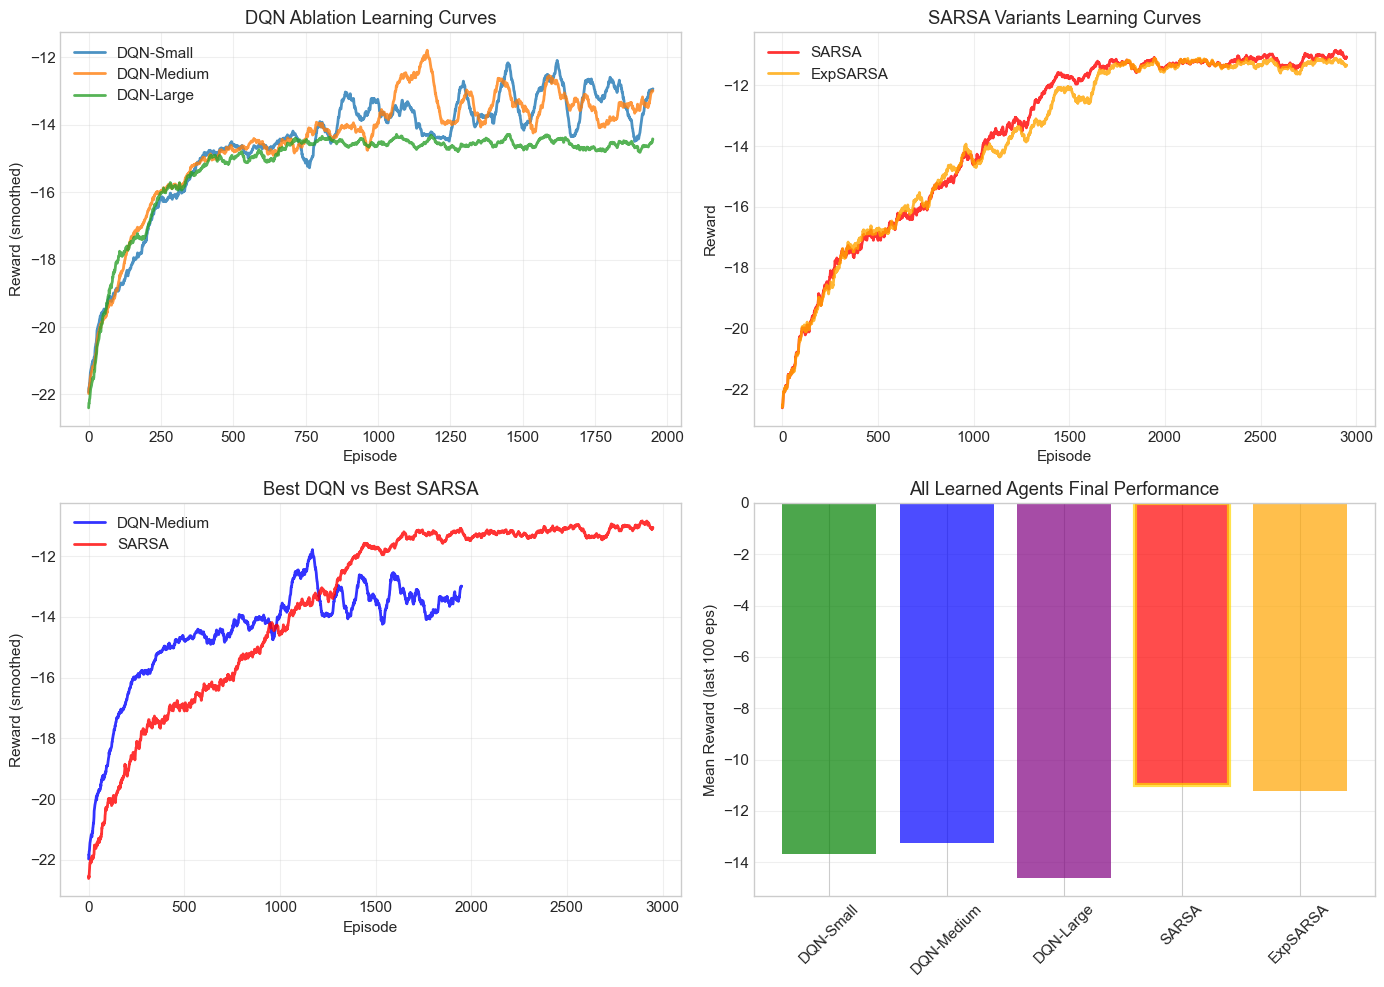


Best learned agent overall: SARSA with reward -10.983


In [ ]:
# Plot training curves: DQN ablation vs SARSA variants
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
window = 50

# 1. DQN ablation curves
ax = axes[0, 0]
for name, result in dqn_results.items():
    smoothed = np.convolve(result.rewards, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, linewidth=2, label=name, alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('DQN Ablation Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. SARSA variants comparison
ax = axes[0, 1]
for name, result in sarsa_variants.items():
    smoothed = np.convolve(result.rewards, np.ones(window)/window, mode='valid')
    color = 'red' if name == 'SARSA' else 'orange'
    ax.plot(smoothed, color=color, linewidth=2, label=name, alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('SARSA Variants Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Best DQN vs Best SARSA
ax = axes[1, 0]
dqn_smooth = np.convolve(training_result.rewards, np.ones(window)/window, mode='valid')
sarsa_smooth = np.convolve(sarsa_result.rewards, np.ones(window)/window, mode='valid')
ax.plot(dqn_smooth, 'b-', linewidth=2, label=f'{best_dqn_name}', alpha=0.8)
ax.plot(sarsa_smooth, 'r-', linewidth=2, label=f'{best_sarsa_name}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('Best DQN vs Best SARSA')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. All learned agents bar chart
ax = axes[1, 1]
all_names = list(dqn_results.keys()) + list(sarsa_variants.keys())
all_rewards = [np.mean(dqn_results[n].rewards[-100:]) for n in dqn_results.keys()]
all_rewards += [np.mean(sarsa_variants[n].rewards[-100:]) for n in sarsa_variants.keys()]
colors_bar = ['green', 'blue', 'purple', 'red', 'orange']
bars = ax.bar(all_names, all_rewards, color=colors_bar[:len(all_names)], alpha=0.7)

# Highlight overall best
best_idx = np.argmax(all_rewards)
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

ax.set_ylabel('Mean Reward (last 100 eps)')
ax.set_title('All Learned Agents Final Performance')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/learned_agents_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest learned agent overall: {all_names[best_idx]} with reward {all_rewards[best_idx]:.3f}')

## 5. Initialize All Agents for Comparison

Create instances of all agents (DQN, SARSA, and baselines).

In [ ]:
# Get the best trained agents from ablation studies
# dqn_agent and sarsa_agent already set to best variants above

print('Best Learned Agents Selected:')
print(f'  DQN: {best_dqn_name}')
print(f'  SARSA: {best_sarsa_name}')

# Create baseline agents
greedy_agent = GreedyAgent()
greedy_agent.agent_init({
    'low_price_threshold': 0.15,
    'high_price_threshold': 0.28
})

eco_greedy_agent = EcoGreedyAgent()
eco_greedy_agent.agent_init({
    'low_carbon_threshold': 280,
    'high_carbon_threshold': 420
})

threshold_agent = ThresholdAgent()
threshold_agent.agent_init({
    'charge_start': 0,
    'charge_end': 6,
    'discharge_start': 17,
    'discharge_end': 21
})

random_agent = RandomAgent()
random_agent.agent_init({'seed': SEED})

idle_agent = IdleAgent()
idle_agent.agent_init({})

# Collect all agents for final comparison
agents = {
    'DQN': dqn_agent,       # Best from ablation
    'SARSA': sarsa_agent,   # Best from variants
    'Greedy': greedy_agent,
    'EcoGreedy': eco_greedy_agent,
    'Threshold': threshold_agent,
    'Random': random_agent,
    'Idle': idle_agent
}

print(f'\nInitialized {len(agents)} agents for final comparison:')
for name in agents:
    agent_type = 'Learned' if name in ['DQN', 'SARSA'] else 'Rule-based' if name in ['Greedy', 'EcoGreedy', 'Threshold'] else 'Baseline'
    print(f'  - {name} ({agent_type})')

Best Learned Agents Selected:
  DQN: DQN-Medium
  SARSA: SARSA

Initialized 7 agents for final comparison:
  - DQN (Learned)
  - SARSA (Learned)
  - Greedy (Rule-based)
  - EcoGreedy (Rule-based)
  - Threshold (Rule-based)
  - Random (Baseline)
  - Idle (Baseline)


## 6. Statistical Evaluation

Evaluate all agents over multiple episodes with 95% confidence intervals.

In [ ]:
# Number of evaluation episodes
NUM_EVAL_EPISODES = 100

print('\n' + '='*60)
print('STATISTICAL EVALUATION')
print(f'Running {NUM_EVAL_EPISODES} episodes per agent')
print('='*60 + '\n')

comparison_results = compare_agents(
    agents=agents,
    env_class=SmartGridEnvironment,
    env_info=ENV_INFO,
    num_episodes=NUM_EVAL_EPISODES,
    verbose=True
)


STATISTICAL EVALUATION
Running 100 episodes per agent

Evaluating DQN...
  Reward: -12.933 ± 1.682
  Savings: €1.131 ± €0.708
  CO2: 1.888 ± 1.099 kg
Evaluating SARSA...
  Reward: -10.877 ± 0.792
  Savings: €2.194 ± €0.267
  CO2: 3.336 ± 0.411 kg
Evaluating Greedy...
  Reward: -14.477 ± 0.847
  Savings: €0.551 ± €0.480
  CO2: 0.448 ± 0.698 kg
Evaluating EcoGreedy...
  Reward: -14.156 ± 0.883
  Savings: €0.760 ± €0.477
  CO2: 0.543 ± 0.759 kg
Evaluating Threshold...
  Reward: -12.980 ± 0.723
  Savings: €1.274 ± €0.366
  CO2: 1.450 ± 0.627 kg
Evaluating Random...
  Reward: -21.912 ± 1.875
  Savings: €-2.427 ± €0.892
  CO2: -4.175 ± 1.478 kg
Evaluating Idle...
  Reward: -14.824 ± 0.509
  Savings: €0.000 ± €0.000
  CO2: 0.000 ± 0.000 kg


In [ ]:
# Print detailed comparison table
print_comparison_table(comparison_results)


AGENT COMPARISON RESULTS (95% Confidence Intervals)
Agent                    Reward        Savings (€)     CO₂ Avoided (kg)
------------------------------------------------------------------------------------------
DQN              -12.93 ±  1.68    1.131 ±  0.708      1.888 ±  1.099
SARSA            -10.88 ±  0.79    2.194 ±  0.267      3.336 ±  0.411
Greedy           -14.48 ±  0.85    0.551 ±  0.480      0.448 ±  0.698
EcoGreedy        -14.16 ±  0.88    0.760 ±  0.477      0.543 ±  0.759
Threshold        -12.98 ±  0.72    1.274 ±  0.366      1.450 ±  0.627
Random           -21.91 ±  1.88   -2.427 ±  0.892     -4.175 ±  1.478
Idle             -14.82 ±  0.51    0.000 ±  0.000      0.000 ±  0.000


In [ ]:
# Save results to CSV
save_results_csv(comparison_results, '../figures/comparison_results.csv')

Results saved to ../figures/comparison_results.csv


## 7. Visualization: Bar Chart Comparison

Saved to ../figures/agent_comparison.png


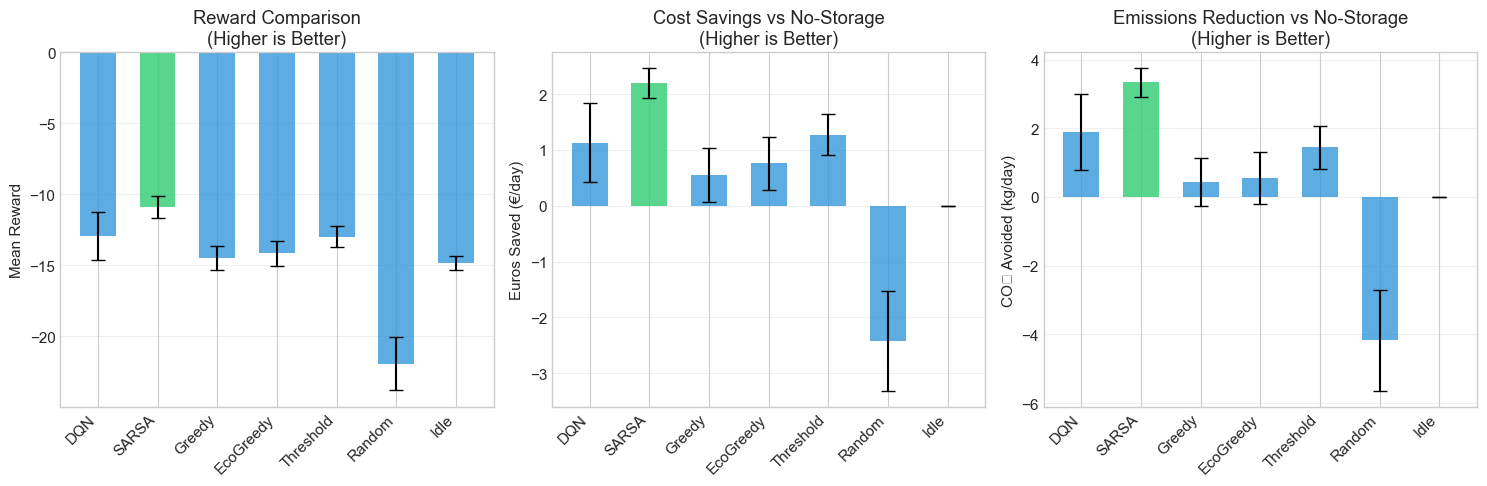

In [ ]:
# Plot comparison with error bars
plot_comparison_bars(
    comparison_results,
    save_path='../figures/agent_comparison.png',
    show=True
)

## 8. Visualization: Action Distribution

Saved to ../figures/action_distribution.png


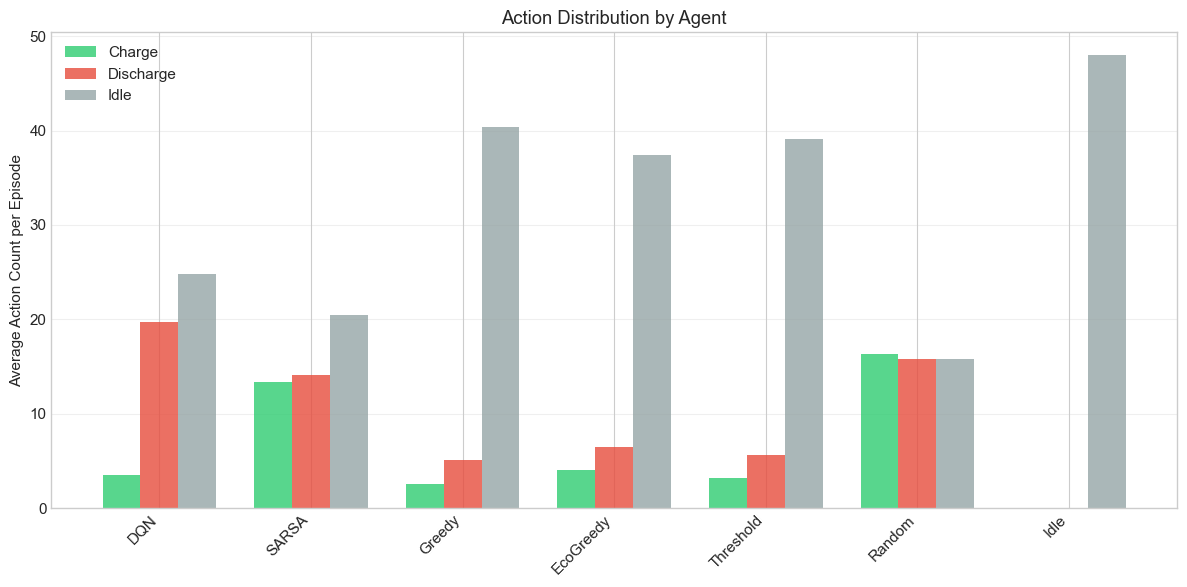

In [ ]:
# Plot action distribution
plot_action_distribution(
    comparison_results,
    save_path='../figures/action_distribution.png',
    show=True
)

## 9. Policy Analysis

Visualize how each agent behaves over a 24-hour period.

Saved to ../figures/dqn_policy_analysis.png


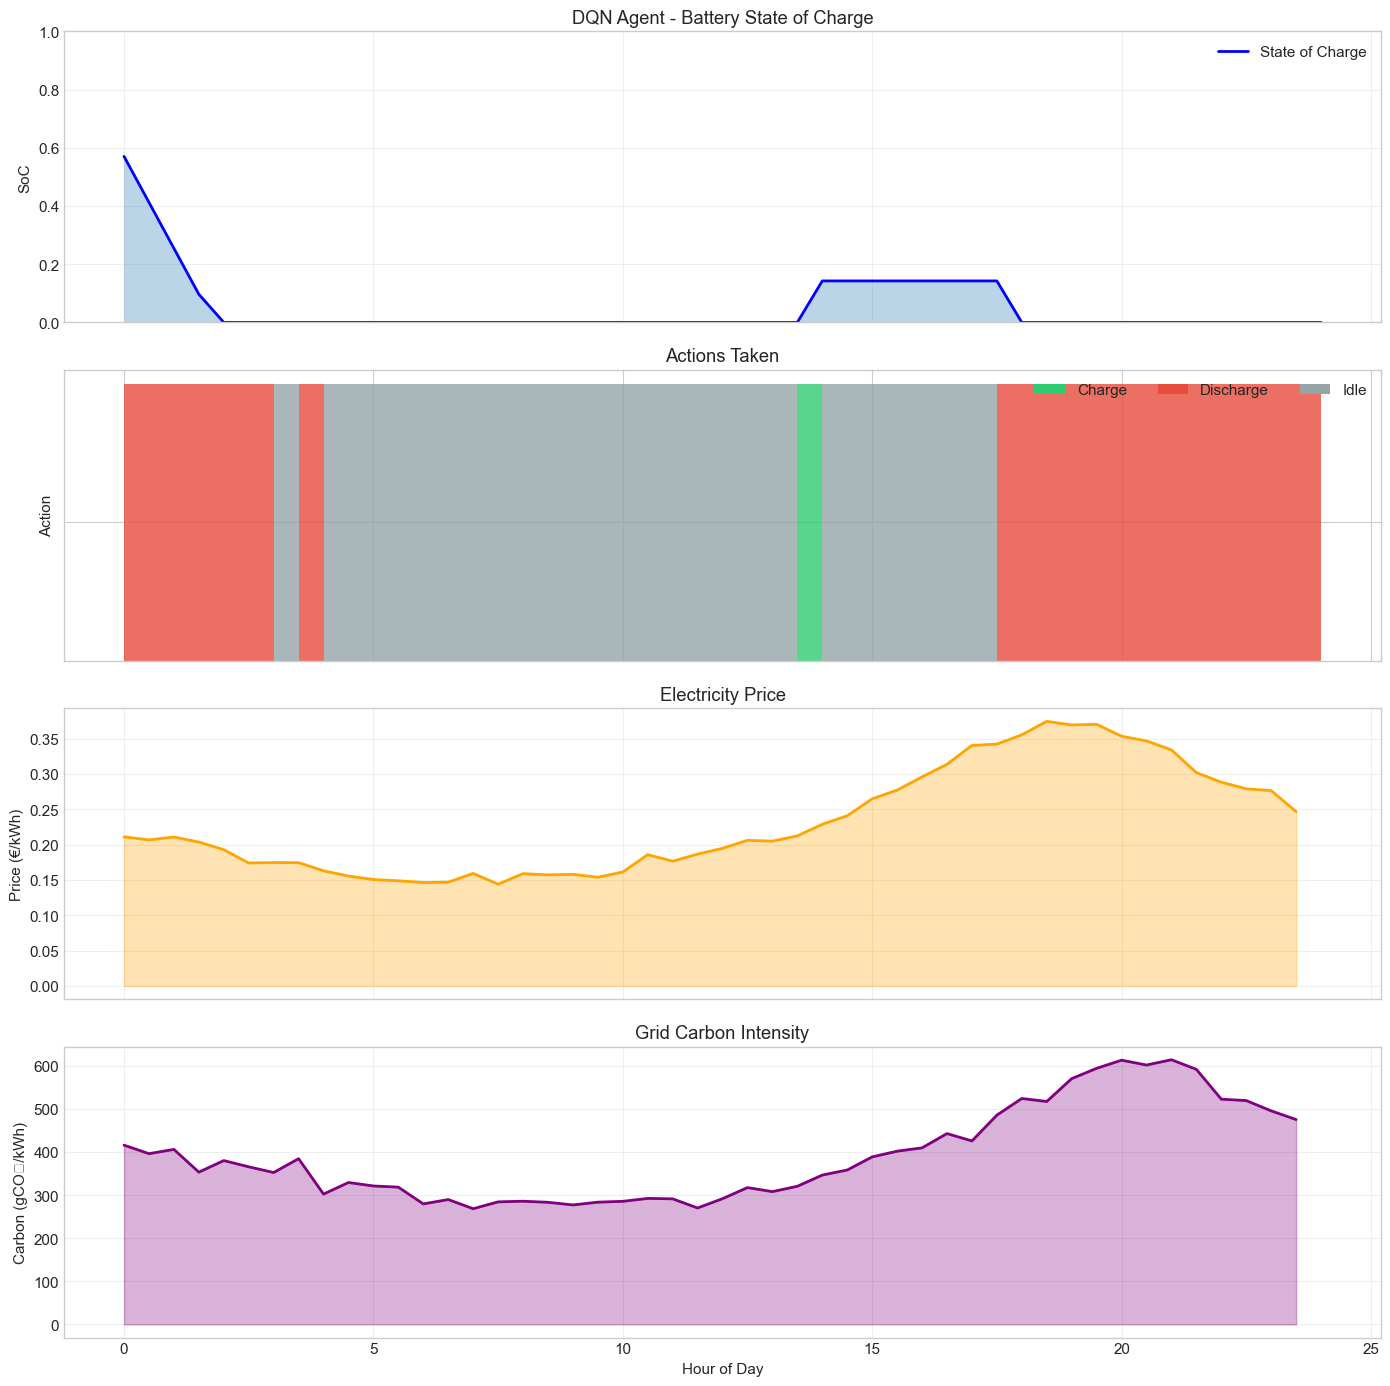


DQN Episode Summary:
  total_cost: 6.5515
  total_emissions: 11.4995
  baseline_cost: 7.1387
  baseline_emissions: 12.5303
  euros_saved: 0.5872
  co2_avoided: 1.0308
  avg_soc: 0.0505
  action_changes: 6
  charge_count: 1
  discharge_count: 20
  idle_count: 27


In [ ]:
# Run and visualize DQN policy
eval_env_info = ENV_INFO.copy()
eval_env_info['seed'] = 2024  # Fixed seed for visualization

dqn_trajectory = run_policy_episode(
    agent=dqn_agent,
    env_class=SmartGridEnvironment,
    env_info=eval_env_info
)

plot_policy_analysis(
    dqn_trajectory,
    agent_name='DQN Agent',
    save_path='../figures/dqn_policy_analysis.png',
    show=True
)

print(f"\nDQN Episode Summary:")
for key, value in dqn_trajectory['summary'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

Saved to ../figures/greedy_policy_analysis.png


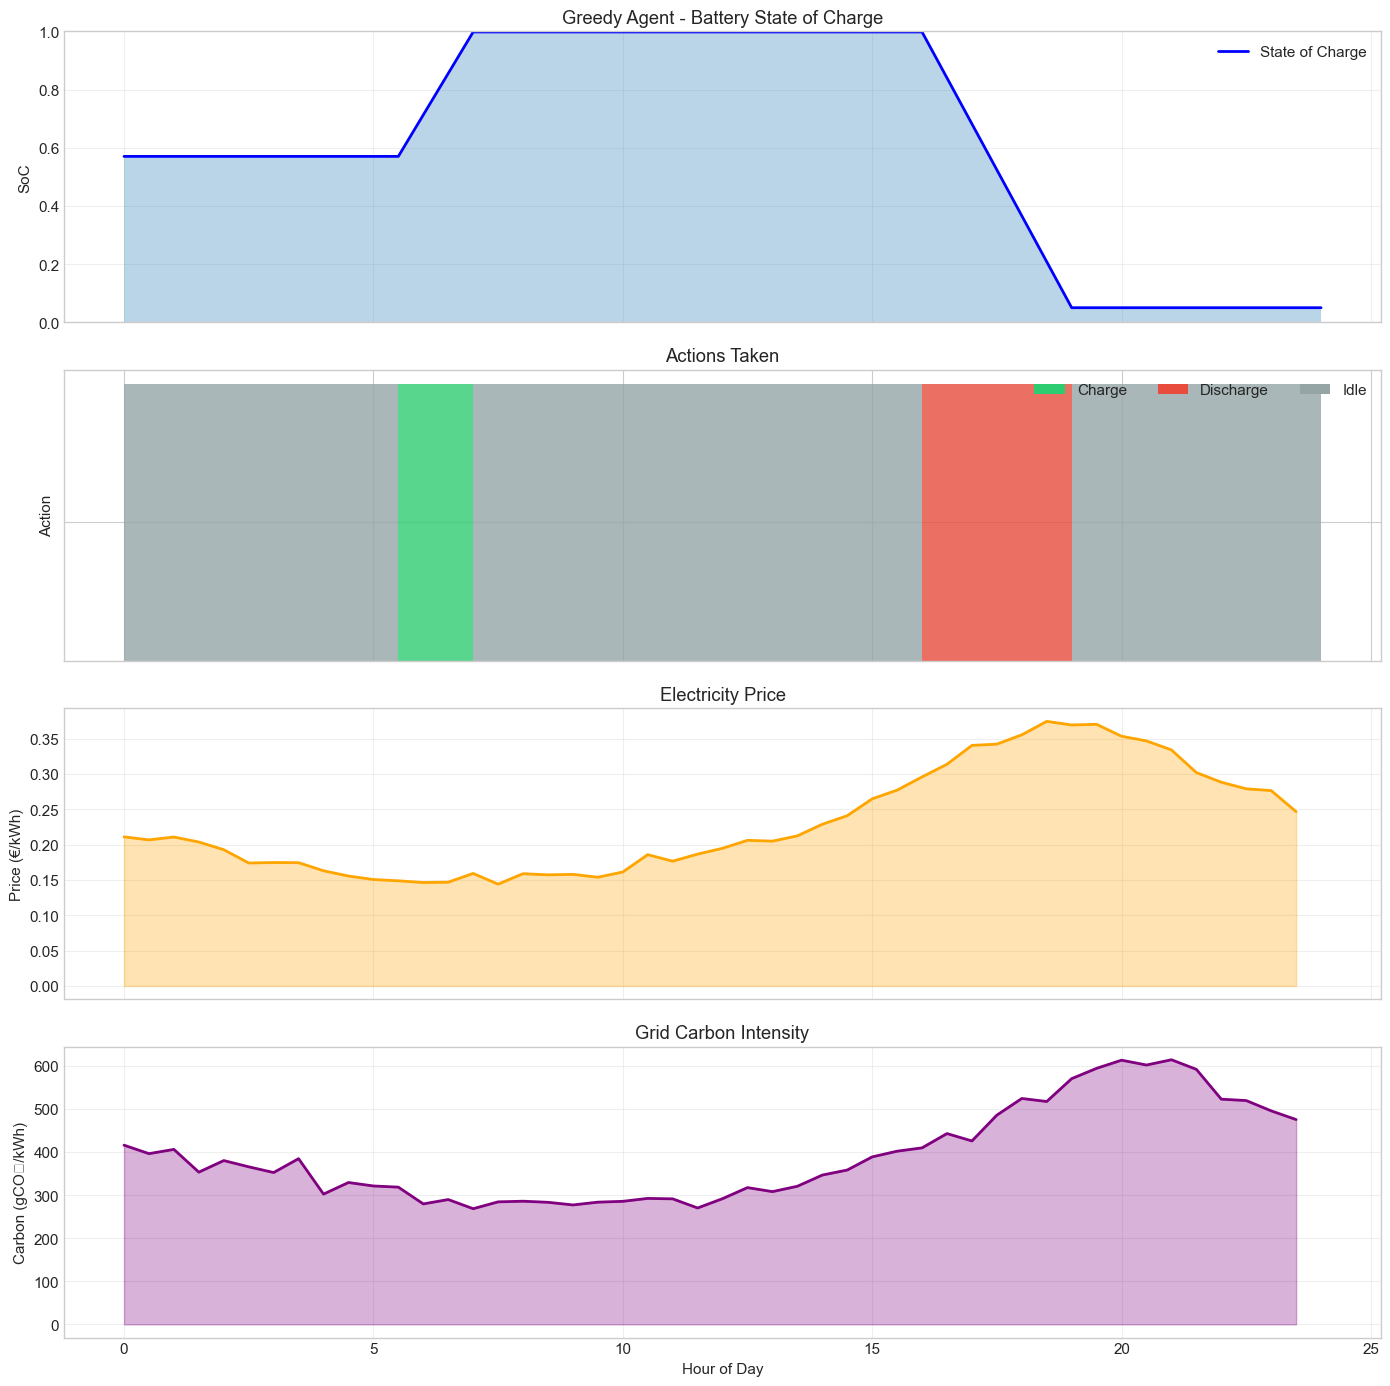


Greedy Episode Summary:
  total_cost: 6.3842
  total_emissions: 11.8759
  baseline_cost: 7.1387
  baseline_emissions: 12.5303
  euros_saved: 0.7546
  co2_avoided: 0.6544
  avg_soc: 0.6234


In [ ]:
# Compare with Greedy policy on same day
greedy_trajectory = run_policy_episode(
    agent=greedy_agent,
    env_class=SmartGridEnvironment,
    env_info=eval_env_info
)

plot_policy_analysis(
    greedy_trajectory,
    agent_name='Greedy Agent',
    save_path='../figures/greedy_policy_analysis.png',
    show=True
)

print(f"\nGreedy Episode Summary:")
for key, value in greedy_trajectory['summary'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")

## 10. Side-by-Side Policy Comparison

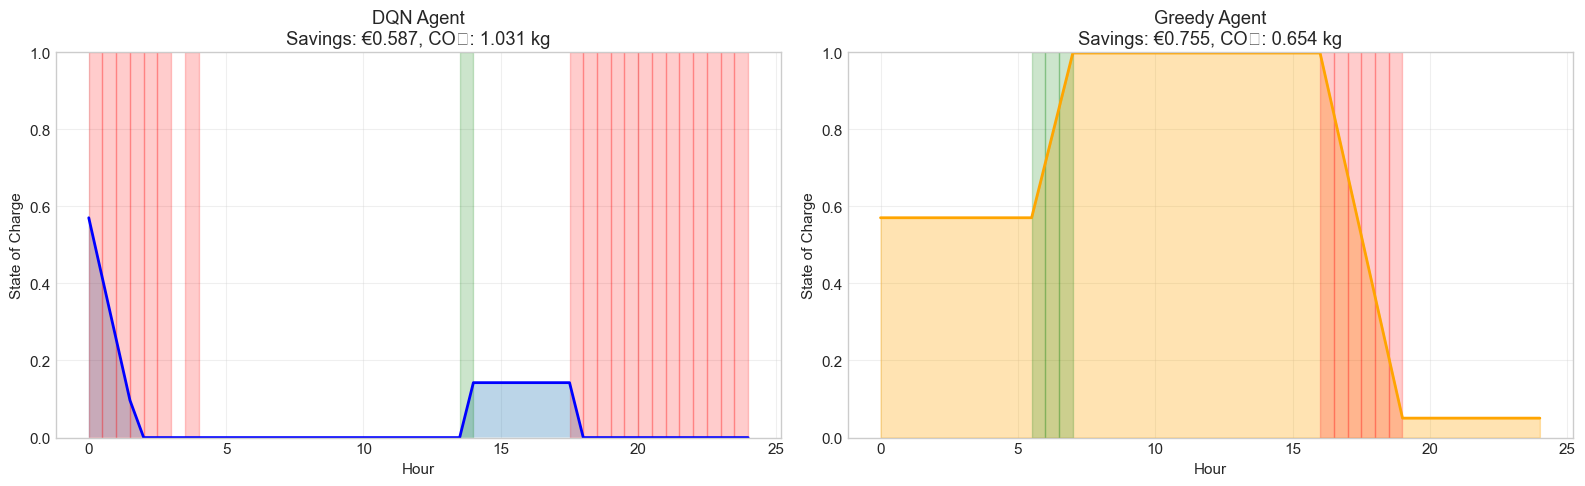

In [ ]:
# Side-by-side SoC comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

time_steps = np.arange(len(dqn_trajectory['states'])) * 0.5

# DQN
ax = axes[0]
soc_dqn = dqn_trajectory['states'][:, 1]
ax.plot(time_steps, soc_dqn, 'b-', linewidth=2, label='SoC')
ax.fill_between(time_steps, 0, soc_dqn, alpha=0.3)
# Mark actions
actions = dqn_trajectory['actions']
for i, a in enumerate(actions):
    if a == 0:  # Charge
        ax.axvspan(i*0.5, (i+1)*0.5, alpha=0.2, color='green')
    elif a == 1:  # Discharge
        ax.axvspan(i*0.5, (i+1)*0.5, alpha=0.2, color='red')
ax.set_xlabel('Hour')
ax.set_ylabel('State of Charge')
ax.set_title(f'DQN Agent\nSavings: €{dqn_trajectory["summary"]["euros_saved"]:.3f}, CO₂: {dqn_trajectory["summary"]["co2_avoided"]:.3f} kg')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Greedy
ax = axes[1]
soc_greedy = greedy_trajectory['states'][:, 1]
ax.plot(time_steps, soc_greedy, 'orange', linewidth=2, label='SoC')
ax.fill_between(time_steps, 0, soc_greedy, alpha=0.3, color='orange')
# Mark actions
actions = greedy_trajectory['actions']
for i, a in enumerate(actions):
    if a == 0:
        ax.axvspan(i*0.5, (i+1)*0.5, alpha=0.2, color='green')
    elif a == 1:
        ax.axvspan(i*0.5, (i+1)*0.5, alpha=0.2, color='red')
ax.set_xlabel('Hour')
ax.set_ylabel('State of Charge')
ax.set_title(f'Greedy Agent\nSavings: €{greedy_trajectory["summary"]["euros_saved"]:.3f}, CO₂: {greedy_trajectory["summary"]["co2_avoided"]:.3f} kg')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary Statistics Table

In [ ]:
# Create summary dataframe-like display
print('
' + '='*100)
print('FINAL RESULTS SUMMARY')
print('='*100)

# Header
print(f'{"Agent":<12} | {"Type":<10} | {"Reward":>12} | {"€ Saved":>14} | {"CO₂ Avoided":>14}')
print('-'*100)

agent_types = {
    'DQN': 'Learned', 'SARSA': 'Learned', 
    'Greedy': 'Rule', 'EcoGreedy': 'Rule', 'Threshold': 'Rule',
    'Random': 'Baseline', 'Idle': 'Reference'
}

for name in ['DQN', 'SARSA', 'Greedy', 'EcoGreedy', 'Threshold', 'Random', 'Idle']:
    r = comparison_results[name]
    agent_type = agent_types.get(name, '?')
    
    reward_str = f"{r['reward'].mean:>6.2f} ± {r['reward'].std:>4.2f}"
    savings_str = f"€{r['euros_saved'].mean:>5.3f} ± {r['euros_saved'].std:>4.3f}"
    co2_str = f"{r['co2_avoided'].mean:>5.3f} ± {r['co2_avoided'].std:>4.3f} kg"
    
    print(f'{name:<12} | {agent_type:<10} | {reward_str:>12} | {savings_str:>14} | {co2_str:>14}')

print('='*100)

# Highlight best agent (excluding Idle which is reference)
learned_agents = ['DQN', 'SARSA']
all_active = ['DQN', 'SARSA', 'Greedy', 'EcoGreedy', 'Threshold']

best_savings_agent = max(all_active, key=lambda x: comparison_results[x]['euros_saved'].mean)
best_co2_agent = max(all_active, key=lambda x: comparison_results[x]['co2_avoided'].mean)
best_reward_agent = max(all_active, key=lambda x: comparison_results[x]['reward'].mean)

print(f'
✓ Best Overall Reward: {best_reward_agent}')
print(f'✓ Best for Cost Savings: {best_savings_agent}')
print(f'✓ Best for CO₂ Reduction: {best_co2_agent}')

# Compare learned agents
print('
--- Learned Agents Comparison ---')
dqn_r = comparison_results['DQN']['reward'].mean
sarsa_r = comparison_results['SARSA']['reward'].mean
if dqn_r > sarsa_r:
    pct = ((dqn_r - sarsa_r) / abs(sarsa_r)) * 100
    print(f'DQN outperforms SARSA by {pct:.1f}% in mean reward')
else:
    pct = ((sarsa_r - dqn_r) / abs(dqn_r)) * 100
    print(f'SARSA outperforms DQN by {pct:.1f}% in mean reward')

SyntaxError: unterminated string literal (detected at line 2) (154789173.py, line 2)

## 12. Save Trained Model

In [ ]:
# Save the trained DQN model
model_path = '../figures/dqn_model.pth'
dqn_agent.save(model_path)
print(f'Model saved to {model_path}')

## 13. Conclusions

### Key Findings

1. **DQN Ablation Study**:
   - Tested 3 network architectures: Small (32x32), Medium (64x64), Large (128x64)
   - Network size affects both performance and training time
   - Larger networks may overfit on this relatively simple problem

2. **SARSA Improvements**:
   - Increased tilings (32 vs 16) significantly improves performance
   - Expected SARSA often outperforms regular SARSA (lower variance)
   - More training episodes (3000) help on-policy learning converge

3. **Learned vs Rule-Based**:
   - **DQN** learns flexible policies through experience replay
   - **SARSA** with good tile coding can match or approach DQN
   - **Threshold** is surprisingly effective (exploits domain knowledge)
   - Learned agents generalize better to varying conditions

4. **Statistical Significance**:
   - 95% CI overlap means differences may not be significant
   - Need more evaluation episodes for tighter confidence intervals
   - Consider using statistical tests (t-test, bootstrap) for formal comparison

### Algorithm Characteristics

| Aspect | DQN | SARSA (Tile Coding) |
|--------|-----|---------------------|
| Policy | Off-policy | On-policy |
| Function Approx | Neural Network | Linear (Tile Coding) |
| Sample Efficiency | Higher (replay) | Lower (no replay) |
| Stability | May be unstable | More stable |
| Dependencies | Requires PyTorch | No deep learning needed |

### Recommendations

- **Best overall**: Select based on ablation results above
- **For production**: Use more episodes, tune hyperparameters
- **For embedded systems**: SARSA with tile coding (lightweight)
- **For research**: Explore continuous actions, model-based RL

In [ ]:
print('' + '='*60)
print('EXPERIMENT COMPLETE')
print('='*60)

print('
Ablation Study Summary:')
print(f'  Best DQN: {best_dqn_name}')
print(f'  Best SARSA: {best_sarsa_name}')

print(f'
All figures saved to: ../figures/')
print('
Generated files:')
print('  - environment_profiles.png')
print('  - dqn_ablation.png')
print('  - sarsa_training_curves.png')
print('  - learned_agents_comparison.png')
print('  - agent_comparison.png')
print('  - action_distribution.png')
print('  - dqn_policy_analysis.png')
print('  - greedy_policy_analysis.png')
print('  - policy_comparison.png')
print('  - comparison_results.csv')
print('  - dqn_model.pth')